In [1]:
# ============================================
# 1. 导入依赖
# ============================================
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector
import numpy as np

from darts import TimeSeries
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler

/home/horeb/miniconda3/envs/darts/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/horeb/miniconda3/envs/darts/lib/python3.12/site-packages/statsforecast/utils.py:231: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "ds": pd.date_range(start="1949-01-01", periods=len(AirPassengers), freq="M"),
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


In [2]:
# ============================================
# 2. 连接 MySQL 并读取数据
# ============================================

db_config = {
    "host": "124.220.77.63",
    "user": "horeb",
    "password": "ZZYzzy4771430///",
    "database": "antarctic_data",
    "charset": "utf8mb4",
}

conn = mysql.connector.connect(**db_config)

query = """
SELECT station, record_time, temperature, humidity, wind_dir, wind_speed
FROM weather_data
ORDER BY record_time ASC
"""

df = pd.read_sql(query, conn)
conn.close()

# 转换时间列
df['record_time'] = pd.to_datetime(df['record_time'])

print(f"数据形状: {df.shape}")
print(f"时间范围: {df['record_time'].min()} 到 {df['record_time'].max()}")
print(f"站点数量: {df['station'].nunique()}")
print(f"各站点数据量:")
print(df['station'].value_counts())

df.head()

/tmp/ipykernel_69602/3673034274.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


数据形状: (15128, 6)
时间范围: 2025-03-17 16:20:00 到 2025-09-07 08:45:00
站点数量: 6
各站点数据量:
station
长城站    4838
中山站    4495
秦岭站    1932
泰山站    1931
昆仑站    1930
黄河站       2
Name: count, dtype: int64


,station,record_time,temperature,humidity,wind_dir,wind_speed
0,长城站,2025-03-17 16:20:00,2.5,99,0,6.5
1,秦岭站,2025-03-17 23:29:00,-20.5,28,280,13.8
2,中山站,2025-03-17 23:31:00,-12.7,57,0,5.0
3,泰山站,2025-03-17 23:32:00,-40.0,69,16,13.6
4,昆仑站,2025-03-17 23:34:00,-60.5,51,162,0.0


长城站数据量: 4838
长城站时间范围: 2025-03-17 16:20:00 到 2025-09-07 03:35:00
长城站数据预览:
   station         record_time  temperature  humidity  wind_dir  wind_speed
0      长城站 2025-03-17 16:20:00          2.5        99         0         6.5
5      长城站 2025-03-17 23:50:00          3.7        93         0         7.7
7      长城站 2025-03-18 00:20:00          3.7        95         0         8.7
9      长城站 2025-03-18 00:50:00          4.0        95         0         5.5
11     长城站 2025-03-18 01:20:00          4.2        95         0         7.9


/home/horeb/miniconda3/envs/darts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/horeb/miniconda3/envs/darts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22478 (\N{CJK UNIFIED IDEOGRAPH-57CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/horeb/miniconda3/envs/darts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31449 (\N{CJK UNIFIED IDEOGRAPH-7AD9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


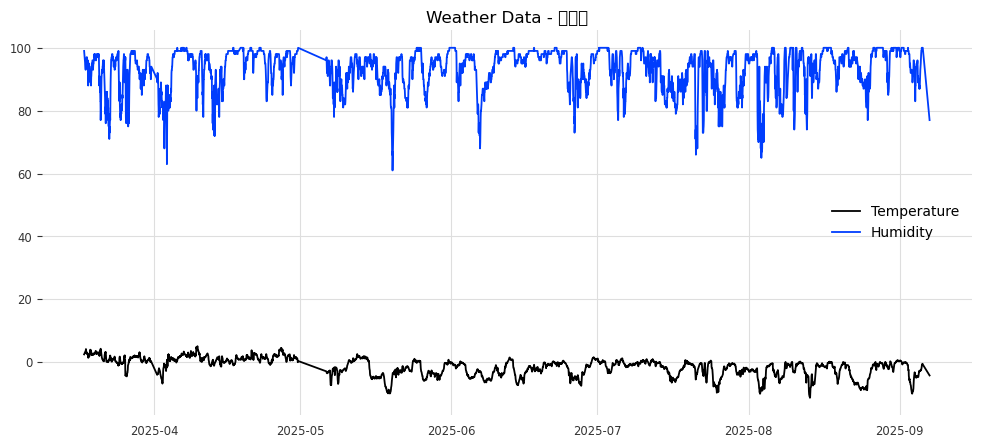

In [4]:
# ============================================
# 3. 数据可视化（单个站点示例）
# ============================================
station = "长城站"  # 要展示的气象站
df_station = df[df["station"] == station]

print(f"长城站数据量: {len(df_station)}")
print(f"长城站时间范围: {df_station['record_time'].min()} 到 {df_station['record_time'].max()}")
print(f"长城站数据预览:")
print(df_station.head())

plt.figure(figsize=(12, 5))
plt.plot(df_station['record_time'], df_station['temperature'], label='Temperature')
plt.plot(df_station['record_time'], df_station['humidity'], label='Humidity')
plt.title(f"Weather Data - {station}")
plt.legend()
plt.show()

训练数据形状: (4838, 6)
时间范围: 2025-03-17 23:20:00 到 2025-09-07 03:35:00
TimeSeries创建成功，长度: 49876


/home/horeb/miniconda3/envs/darts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/horeb/miniconda3/envs/darts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22478 (\N{CJK UNIFIED IDEOGRAPH-57CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/horeb/miniconda3/envs/darts/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31449 (\N{CJK UNIFIED IDEOGRAPH-7AD9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


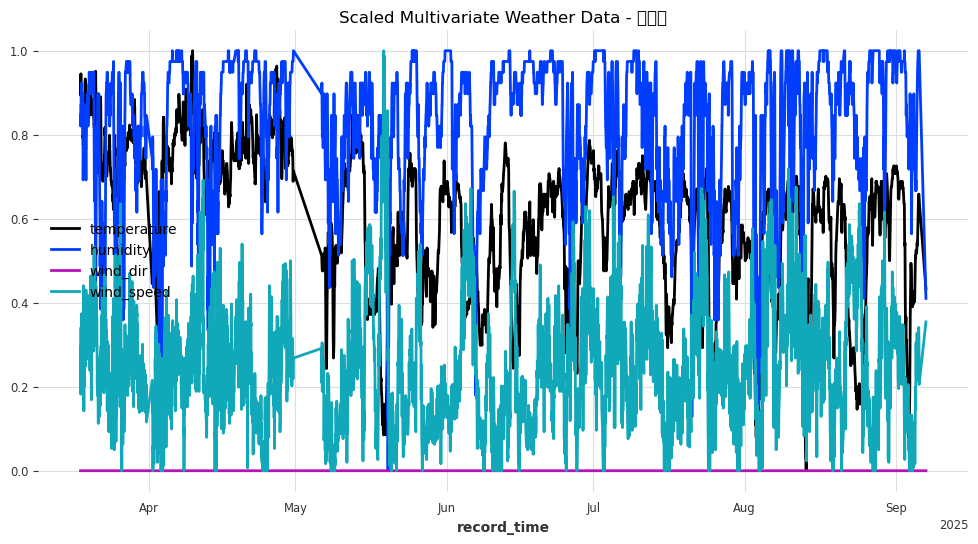

In [15]:
# ============================================
# 4. 转换为 Darts TimeSeries
# ============================================
# 选择一个站点训练
df_train = df[df["station"] == station].copy()
df_train = df_train.sort_values('record_time').reset_index(drop=True)

print(f"训练数据形状: {df_train.shape}")
print(f"时间范围: {df_train['record_time'].min()} 到 {df_train['record_time'].max()}")

# ✅ 确保时间列为 datetime，并去掉 tz 信息
df_train["record_time"] = pd.to_datetime(df_train["record_time"], errors="coerce").dt.tz_localize(None)

# ✅ 只保留需要的数值列 + 时间列
value_cols = ["temperature", "humidity", "wind_dir", "wind_speed"]
df_train[value_cols] = df_train[value_cols].apply(pd.to_numeric, errors="coerce")

# ✅ 设置时间为索引并重采样 (这里用 5 分钟，可以改成 '1H' 等)
df_train = df_train.set_index("record_time")[value_cols].resample("5min").mean()

# ✅ 插值填补缺失
df_train = df_train.interpolate(method="time")

# ✅ 重建索引列
df_train = df_train.reset_index()

# ✅ 创建TimeSeries
series = TimeSeries.from_dataframe(
    df_train,
    time_col="record_time",
    value_cols=value_cols,
    fill_missing_dates=True,
    freq="5min"
)

print(f"TimeSeries创建成功，长度: {len(series)}")

# 数据缩放
scaler = Scaler()
series_scaled = scaler.fit_transform(series)

# 绘制图表
plt.figure(figsize=(12, 6))
series_scaled.plot()
plt.title(f"Scaled Multivariate Weather Data - {station}")
plt.show()


In [ ]:
# ============================================
# 5. 划分训练集和验证集
# ============================================
# 验证集：最后7天的数据
val_size = min(7 * 24 * 12, len(series_scaled) // 10)  # 7天或总数据的10%，取较小值
train, val = series_scaled[:-val_size], series_scaled[-val_size:]

print(f"训练集长度: {len(train)}")
print(f"验证集长度: {len(val)}")
print(f"训练集时间范围: {train.start_time()} 到 {train.end_time()}")
print(f"验证集时间范围: {val.start_time()} 到 {val.end_time()}")


训练集长度: 47860
验证集长度: 2016
训练集时间范围: 2025-03-17 23:20:00 到 2025-08-31 03:35:00
验证集时间范围: 2025-08-31 03:40:00 到 2025-09-07 03:35:00


In [18]:
# ============================================
# 6. 定义并训练 TFT 模型
# ============================================
model = TFTModel(
    input_chunk_length=24,   # 输入窗口 24 步
    output_chunk_length=6,   # 预测未来 6 步
    hidden_size=32,
    n_epochs=1,             # 训练轮数
    batch_size=16,
    add_relative_index=True,
    random_state=42,
    optimizer_kwargs={"lr": 0.001},  # 学习率
    lr_scheduler_cls=None,           # 不用调度器
    dropout=0.1,                     # dropout 防止过拟合
    force_reset=True                 # 每次训练重新初始化
)

print("开始训练模型...")
print(f"训练数据形状: {train.all_values().shape}")
print(f"验证数据形状: {val.all_values().shape}")

model.fit(train, val_series=val, verbose=True)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 5.0 K  | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 896    | train
6  | static_context_grn                | _GatedResidualNetwork            | 4.3 K  | train
7  | static_context_hidden_encoder_grn | _GatedResidualNetwork            | 4.3 K  | train
8  | static_context_cell_encoder_grn   | _GatedResidualNetwork            | 4.3 K  

开始训练模型...
训练数据形状: (47860, 4, 1)
验证数据形状: (2016, 4, 1)
Epoch 0: 100%|██████████| 2990/2990 [01:07<00:00, 44.18it/s, train_loss=0.0804, val_loss=0.0648]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 2990/2990 [01:07<00:00, 44.18it/s, train_loss=0.0804, val_loss=0.0648]


TFTModel(output_chunk_shift=0, hidden_size=32, lstm_layers=1, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=True, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=24, output_chunk_length=6, n_epochs=1, batch_size=16, random_state=42, optimizer_kwargs={'lr': 0.001}, lr_scheduler_cls=None, force_reset=True)

<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_268709/1803513667.py:45: SyntaxWarning: invalid escape sequence '\p'
  f"actual scale: [{val_series.values().min():.2f}, {val_series.values().max():.2f}]\predict scale: [{forecast_series.values().min():.2f}, {forecast_series.values().max():.2f}]",
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


=== 开始预测 ===
训练数据长度: 47860
验证数据长度: 2016
使用验证集进行预测...
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  1.68it/s]
✅ 预测完成
预测结果长度: 2016
预测时间范围: 2025-08-31 03:40:00 到 2025-09-07 03:35:00
预测数据统计: min=-0.0264, max=1.1890, mean=0.5182


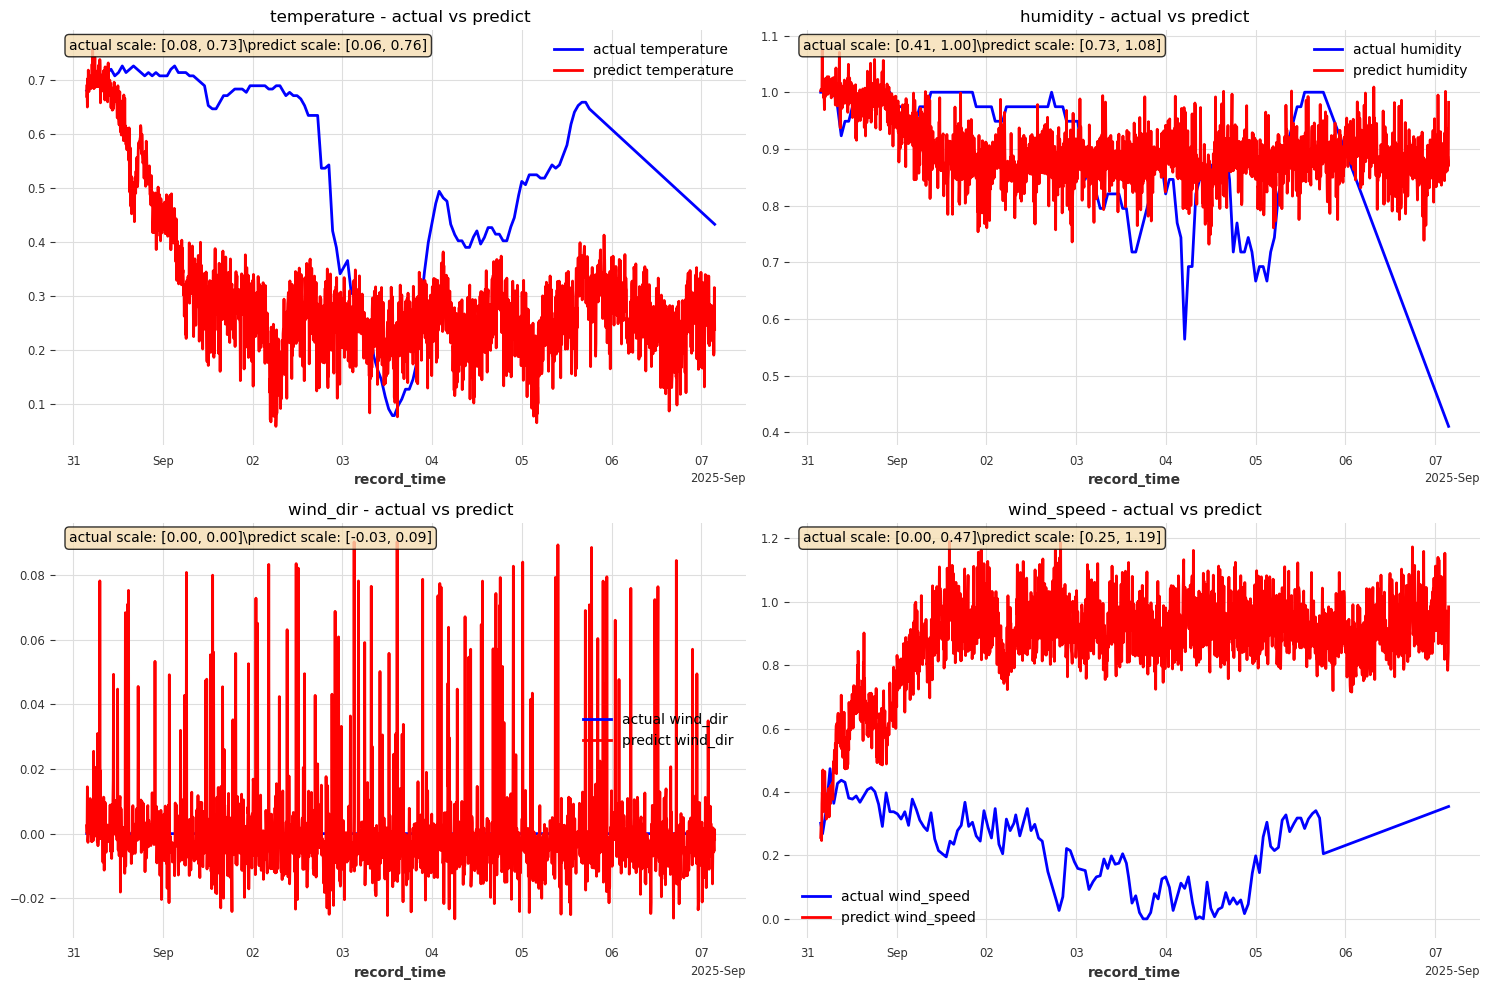


=== 预测误差统计 ===
temperature: MAE=0.2461, MSE=0.0782
humidity: MAE=0.1065, MSE=0.0202
wind_dir: MAE=0.0086, MSE=0.0002
wind_speed: MAE=0.6462, MSE=0.4628


In [26]:
# ============================================
# 7. 预测并可视化
# ============================================
print("=== 开始预测 ===")
print(f"训练数据长度: {len(train)}")
print(f"验证数据长度: {len(val)}")

if model is None:
    print("❌ 模型未训练成功")
else:
    try:
        # 使用验证集进行预测
        print("使用验证集进行预测...")
        forecast = model.predict(n=len(val), series=train)

        print("✅ 预测完成")
        print(f"预测结果长度: {len(forecast)}")
        print(f"预测时间范围: {forecast.start_time()} 到 {forecast.end_time()}")

        forecast_values = forecast.all_values()
        print(f"预测数据统计: min={forecast_values.min():.4f}, max={forecast_values.max():.4f}, mean={forecast_values.mean():.4f}")

        if np.all(forecast_values == 0):
            print("⚠️ 警告：预测结果全为0")
        elif np.isnan(forecast_values).all():
            print("⚠️ 警告：预测结果全为NaN")

        # 绘制结果
        plt.figure(figsize=(15, 10))
        for i, col in enumerate(['temperature', 'humidity', 'wind_dir', 'wind_speed']):
            plt.subplot(2, 2, i+1)
            val_series = val.univariate_component(col)
            forecast_series = forecast.univariate_component(col)

            val_series.plot(label=f"actual {col}", color='blue', linewidth=2)
            forecast_series.plot(label=f"predict {col}", color='red', linewidth=2)

            plt.title(f"{col} - actual vs predict")
            plt.legend()
            plt.grid(True)

            # 数值范围
            plt.text(
                0.02, 0.98,
                f"actual scale: [{val_series.values().min():.2f}, {val_series.values().max():.2f}]\predict scale: [{forecast_series.values().min():.2f}, {forecast_series.values().max():.2f}]",
                transform=plt.gca().transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
            )

        plt.tight_layout()
        plt.show()

        # 误差指标
        from darts.metrics import mae, mse
        print("\n=== 预测误差统计 ===")
        for col in ['temperature', 'humidity', 'wind_dir', 'wind_speed']:
            actual = val.univariate_component(col)
            predicted = forecast.univariate_component(col)

            print(f"{col}: MAE={mae(actual, predicted):.4f}, MSE={mse(actual, predicted):.4f}")

    except Exception as e:
        print(f"❌ 预测失败: {e}")
        import traceback
        traceback.print_exc()


In [28]:
# ============================================
# 8. 保存模型和Scaler
# ============================================
import pickle

# 保存模型
model.save("tft_model.pt")
print("✅ 模型已保存到 tft_model.pt")

# 保存 Scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✅ Scaler 已保存到 scaler.pkl")

# 保存训练信息
training_info = {
    "station": station,
    "train_length": len(train),
    "val_length": len(val),
    "freq": "5min",
    "input_chunk_length": 24,
    "output_chunk_length": 6,
    "features": ["temperature", "humidity", "wind_dir", "wind_speed"]
}
with open("training_info.pkl", "wb") as f:
    pickle.dump(training_info, f)
print("✅ 训练信息已保存到 training_info.pkl")

print("\n模型训练完成！")
print(f"训练集: {len(train)} 个数据点")
print(f"验证集: {len(val)} 个数据点")
print(f"特征: {training_info['features']}")


✅ 模型已保存到 tft_model.pt
✅ Scaler 已保存到 scaler.pkl
✅ 训练信息已保存到 training_info.pkl

模型训练完成！
训练集: 47860 个数据点
验证集: 2016 个数据点
特征: ['temperature', 'humidity', 'wind_dir', 'wind_speed']


In [29]:
# ============================================
# 9. 数据质量检查和诊断
# ============================================
print("=== 数据质量诊断 ===")

# 检查原始数据
print(f"原始数据形状: {df.shape}")
print(f"各站点数据量:")
station_counts = df['station'].value_counts()
print(station_counts)

# 检查时间间隔
print(f"\n时间间隔分析:")
for station_name in df['station'].unique()[:3]:  # 只检查前3个站点
    station_data = df[df['station'] == station_name].sort_values('record_time')
    if len(station_data) > 1:
        time_diffs = station_data['record_time'].diff().dropna()
        print(f"{station_name}: 平均间隔 {time_diffs.mean()}, 最小间隔 {time_diffs.min()}, 最大间隔 {time_diffs.max()}")

# 检查数值范围
print(f"\n数值范围检查:")
for col in ['temperature', 'humidity', 'wind_dir', 'wind_speed']:
    print(f"{col}: 最小值={df[col].min():.2f}, 最大值={df[col].max():.2f}, 平均值={df[col].mean():.2f}")

# 检查缺失值
print(f"\n缺失值统计:")
print(df.isnull().sum())


=== 数据质量诊断 ===
原始数据形状: (15133, 6)
各站点数据量:
station
长城站    4838
中山站    4496
秦岭站    1933
泰山站    1932
昆仑站    1931
黄河站       3
Name: count, dtype: int64

时间间隔分析:
黄河站: 平均间隔 69 days 15:30:00, 最小间隔 33 days 00:00:00, 最大间隔 106 days 07:00:00
泰山站: 平均间隔 0 days 02:08:04.443293630, 最小间隔 0 days 00:31:00, 最大间隔 5 days 20:02:00
昆仑站: 平均间隔 0 days 02:08:08.611398963, 最小间隔 0 days 00:30:00, 最大间隔 5 days 20:29:00

数值范围检查:
temperature: 最小值=-78.20, 最大值=5.10, 平均值=-21.55
humidity: 最小值=1.00, 最大值=101.00, 平均值=66.52
wind_dir: 最小值=0.00, 最大值=511.00, 平均值=64.51
wind_speed: 最小值=0.00, 最大值=97.10, 平均值=7.88

缺失值统计:
station        0
record_time    0
temperature    0
humidity       0
wind_dir       0
wind_speed     0
dtype: int64


In [ ]:
# ============================================
# 10. 简单测试 - 验证数据是否正常
# ============================================
print("=== 数据验证测试 ===")

# 检查原始数据
print(f"原始数据总行数: {len(df)}")
print(f"站点列表: {df['station'].unique()}")

# 检查长城站数据
station = "长城站"
df_station = df[df["station"] == station]
print(f"\n{station} 数据:")
print(f"数据行数: {len(df_station)}")
if len(df_station) > 0:
    print(f"时间范围: {df_station['record_time'].min()} 到 {df_station['record_time'].max()}")
    print(f"数据预览:")
    print(df_station[['record_time', 'temperature', 'humidity', 'wind_dir', 'wind_speed']].head())
    
    # 简单绘图测试
    plt.figure(figsize=(12, 6))
    plt.plot(df_station['record_time'], df_station['temperature'], 'b-', label='Temperature')
    plt.plot(df_station['record_time'], df_station['humidity'], 'r-', label='Humidity')
    plt.title(f"原始数据 - {station}")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print(f"❌ {station} 没有数据！")
